# NOAA Global Hourly: Glasgow Airport

Download NOAA observations for Glasgow Airport, clean packed weather fields, and plot temperature and wind speed.

In [ ]:
project_root = isfile(joinpath(pwd(), "julia_code", "noaa_global_hourly.jl")) ? pwd() : dirname(pwd())
include(joinpath(project_root, "julia_code", "noaa_global_hourly.jl"))
include(joinpath(project_root, "julia_code", "models.jl"))
include(joinpath(project_root, "julia_code", "evaluation.jl"))
using DataFrames
using Statistics: mean, std

In [ ]:
station = "03140099999"
station_name = "Glasgow Airport (EGPF)"
records = fetch_global_hourly(station, "2024-01-01", "2024-01-31")
println("Downloaded $(nrow(records)) records with $(ncol(records)) fields.")
first(records, min(5, nrow(records)))

┌ Warning: `readtimeout` is deprecated; use `read_idle_timeout` for inactivity timeouts or `request_timeout` for overall request deadlines
└ @ HTTP C:\Users\vd14v\.julia\packages\HTTP\r4KEz\src\http_client_timeouts.jl:41


Downloaded 1485 records with 29 fields.


Row,GA3,STATION,WND,MA1,LONGITUDE,TMP,CALL_SIGN,SLP,AW1,EQD,VIS,GA1,REPORT_TYPE,GE1,ED1,REM,OC1,MW1,LATITUDE,QUALITY_CONTROL,DATE,GF1,AW2,NAME,ELEVATION,CIG,DEW,GA2,SOURCE
,String?,String,String,String,String,String,String,String,String?,String?,String,String?,String,String?,String?,String,String?,String?,String,String,String,String?,String?,String,String,String,String,String?,String
1,missing,03140099999,"250,1,N,0010,1","09870,1,99999,9",-4.433056,"+0030,1",99999,"99999,9",missing,missing,"009999,1,9,9","08,1,+00914,1,99,9",FM-15,"9,AGL ,+99999,+99999",missing,MET056METAR EGPF 010020Z AUTO 25002KT 9999 OVC030 03/02 Q0987=,missing,missing,55.871944,V020,2024-01-01T00:20:00,"99,99,9,08,1,99,9,00914,1,99,9,99,9",missing,"GLASGOW, UK",7.92,"00914,1,C,N","+0020,1",missing,4
2,missing,03140099999,"999,9,V,0005,1","09880,1,99999,9",-4.433056,"+0030,1",99999,"99999,9",missing,missing,"009999,1,9,9","08,1,+00914,1,99,9",FM-15,"9,AGL ,+99999,+99999",missing,MET056METAR EGPF 010050Z AUTO VRB01KT 9999 OVC030 03/02 Q0988=,missing,missing,55.871944,V020,2024-01-01T00:50:00,"99,99,9,08,1,99,9,00914,1,99,9,99,9",missing,"GLASGOW, UK",7.92,"00914,1,C,N","+0020,1",missing,4
3,missing,03140099999,"190,1,N,0010,1","09880,1,99999,9",-4.433056,"+0030,1",99999,"99999,9",missing,missing,"009999,1,9,9","07,1,+00884,1,99,9",FM-15,"9,AGL ,+99999,+99999",missing,MET063METAR EGPF 010120Z AUTO 19002KT 9999 BKN029 OVC033 03/02 Q0988=,missing,missing,55.871944,V020,2024-01-01T01:20:00,"99,99,9,07,1,99,9,00884,1,99,9,99,9",missing,"GLASGOW, UK",7.92,"00884,1,C,N","+0020,1","08,1,+01006,1,99,9",4
4,missing,03140099999,"220,1,N,0015,1","09880,1,99999,9",-4.433056,"+0030,1",99999,"99999,9",missing,missing,"009999,1,9,9","08,1,+00823,1,99,9",FM-15,"9,AGL ,+99999,+99999",missing,MET056METAR EGPF 010150Z AUTO 22003KT 9999 OVC027 03/02 Q0988=,missing,missing,55.871944,V020,2024-01-01T01:50:00,"99,99,9,08,1,99,9,00823,1,99,9,99,9",missing,"GLASGOW, UK",7.92,"00823,1,C,N","+0020,1",missing,4
5,missing,03140099999,"230,1,N,0026,1","09890,1,99999,9",-4.433056,"+0030,1",99999,"99999,9",missing,missing,"009999,1,9,9","08,1,+00732,1,99,9",FM-15,"9,AGL ,+99999,+99999",missing,MET069METAR EGPF 010220Z AUTO 23005KT 9999 OVC024/// //////TCU 03/02 Q0989=,missing,missing,55.871944,V020,2024-01-01T02:20:00,"99,99,9,08,1,99,9,00732,1,99,9,99,9",missing,"GLASGOW, UK",7.92,"00732,1,C,N","+0020,1",missing,4


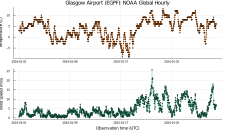

In [ ]:
cleaned = clean_global_hourly(records)
select(cleaned, :DATE, :temperature_c, :dew_point_c, :visibility_km, :wind_speed_mps) |> first
plot_weather(cleaned; station_name = station_name)

## Forecasting temperature with an LSTM and a classic feed-forward network

Interpolate short gaps in the temperature series, normalize it, and build sliding-window
sequences. The last 20% of the series (chronologically) is held out as a test set so we can
evaluate one-step-ahead forecasts on unseen data. Both models consume the same
`(1, lookback, samples)` windows and are trained with the same generic `train_forecaster`
function, so their forecasts can be compared directly.


In [ ]:
lookback = 24
test_fraction = 0.2

fill_value = mean(skipmissing(cleaned.temperature_c))
temperature = Float32.(coalesce.(cleaned.temperature_c, fill_value))
series_mean, series_std = mean(temperature), std(temperature)
normalized = (temperature .- series_mean) ./ series_std

X, y = make_supervised_sequences(normalized; lookback = lookback)
sequence_dates = cleaned.DATE[(lookback + 1):end]

split_idx = floor(Int, size(X)[end] * (1 - test_fraction))
X_train, X_test = X[:, :, 1:split_idx], X[:, :, (split_idx + 1):end]
y_train, y_test = y[:, 1:split_idx], y[:, (split_idx + 1):end]
dates_test = sequence_dates[(split_idx + 1):end]

println("Train sequences: $(size(X_train)[end]), test sequences: $(size(X_test)[end])")


Train sequences: 1168, test sequences: 293


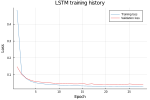

In [ ]:
lstm_model = LSTMForecaster(; units = 32, horizon = 1)
lstm_history = train_forecaster(lstm_model, X_train, y_train; epochs = 100, batch_size = 16)
plot_training_history(lstm_history; title = "LSTM training history")


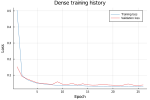

In [ ]:
dense_model = DenseForecaster(; lookback = lookback, units = 32, horizon = 1)
dense_history = train_forecaster(dense_model, X_train, y_train; epochs = 100, batch_size = 16)
plot_training_history(dense_history; title = "Dense training history")


LSTM Dict("mape" => 9.493, "rmse" => 0.656, "r2" => 0.949, "mae" => 0.428)


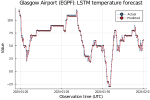

Dense Dict("mape" => 12.144, "rmse" => 0.774, "r2" => 0.93, "mae" => 0.567)


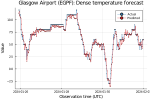

In [ ]:
actual = vec(y_test) .* series_std .+ series_mean

for (name, model) in [("LSTM", lstm_model), ("Dense", dense_model)]
    predicted_norm = model(X_test)
    predicted = vec(predicted_norm) .* series_std .+ series_mean

    metrics = evaluate_forecast(actual, predicted)
    println(name, " ", Dict(key => round(value; digits = 3) for (key, value) in metrics))

    display(plot_predictions(actual, predicted; dates = dates_test, title = "$(station_name): $(name) temperature forecast"))
end
